# EDA and FE

### Imports

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [27]:
df_copy = pd.read_csv("../dataset/code_dataset.csv")
df = df_copy
df.head()

,code,loops,maxDepth,recursion,label
0,public int sumArray(int[] arr) {\n int sum = ...,1,1,False,Efficient
1,"public int binarySearch(int[] arr, int target)...",1,1,False,Efficient
2,public void bubbleSort(int[] arr) {\n for (in...,2,2,False,Inefficient
3,public int factorial(int n) {\n if (n <= 1) r...,0,0,True,Efficient
4,public int fibonacci(int n) {\n if (n <= 1) r...,0,0,True,Inefficient


In [28]:
df.shape

(100, 5)

In [29]:
df.info

<bound method DataFrame.info of                                                  code  loops  maxDepth  \
0   public int sumArray(int[] arr) {\n  int sum = ...      1         1   
1   public int binarySearch(int[] arr, int target)...      1         1   
2   public void bubbleSort(int[] arr) {\n  for (in...      2         2   
3   public int factorial(int n) {\n  if (n <= 1) r...      0         0   
4   public int fibonacci(int n) {\n  if (n <= 1) r...      0         0   
..                                                ...    ...       ...   
95  public int minCoinsRecursive(int[] coins, int ...      1         1   
96  public int[][] transposeMatrix(int[][] mat) {\...      2         2   
97  public int hammingWeight(int n) {\n  int count...      1         1   
98  public int allPairsShortestPath(int[][] dist, ...      3         3   
99  public int solve(int n) {\n  return n * (n + 1...      0         0   

    recursion        label  
0       False    Efficient  
1       False    Effi

In [30]:
df.describe

<bound method NDFrame.describe of                                                  code  loops  maxDepth  \
0   public int sumArray(int[] arr) {\n  int sum = ...      1         1   
1   public int binarySearch(int[] arr, int target)...      1         1   
2   public void bubbleSort(int[] arr) {\n  for (in...      2         2   
3   public int factorial(int n) {\n  if (n <= 1) r...      0         0   
4   public int fibonacci(int n) {\n  if (n <= 1) r...      0         0   
..                                                ...    ...       ...   
95  public int minCoinsRecursive(int[] coins, int ...      1         1   
96  public int[][] transposeMatrix(int[][] mat) {\...      2         2   
97  public int hammingWeight(int n) {\n  int count...      1         1   
98  public int allPairsShortestPath(int[][] dist, ...      3         3   
99  public int solve(int n) {\n  return n * (n + 1...      0         0   

    recursion        label  
0       False    Efficient  
1       False    Ef

In [31]:
df.isnull().sum() ## this means that we have no null values

code         0
loops        0
maxDepth     0
recursion    0
label        0
dtype: int64

In [32]:
df.duplicated().sum() ## no duplicate values in the dataset as well

np.int64(0)

## Data understanding

### - loops → number of loops in code
### - maxDepth → nesting depth of loops
### - recursion → whether function is recursive
### - label → efficiency class (target)

## Visualization of the dataset

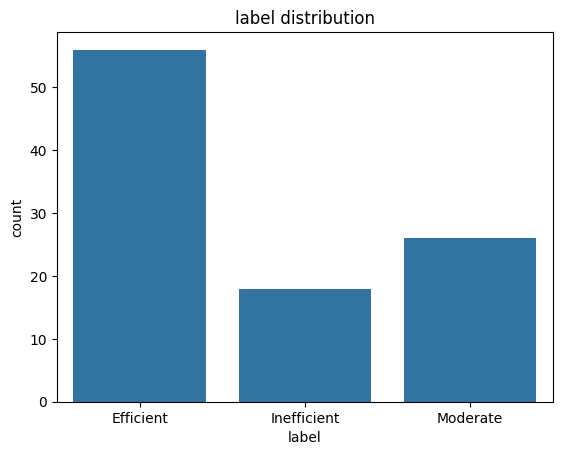

In [33]:
#label distrucbution
sns.countplot(x='label', data=df)
plt.title('label distribution')
plt.show()

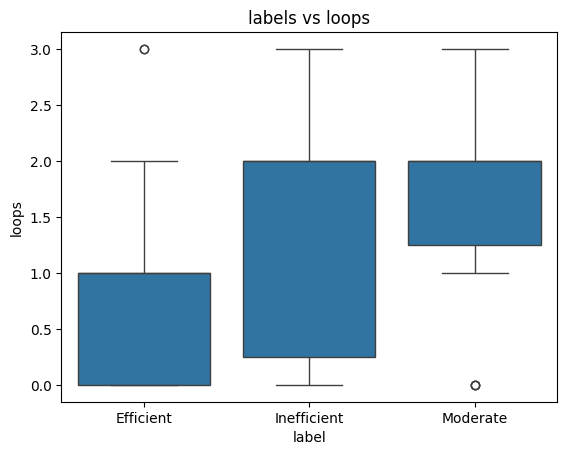

In [34]:
#loop vs label
sns.boxplot(x='label', y='loops', data=df)
plt.title('labels vs loops')
plt.show()

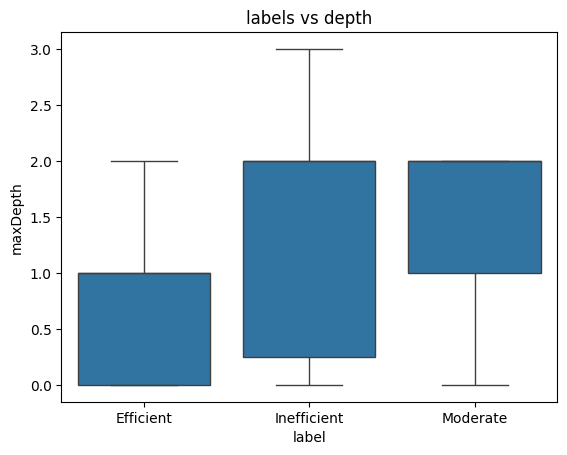

In [35]:
#depth vs label
sns.boxplot(x='label', y='maxDepth', data=df)
plt.title('labels vs depth')
plt.show()

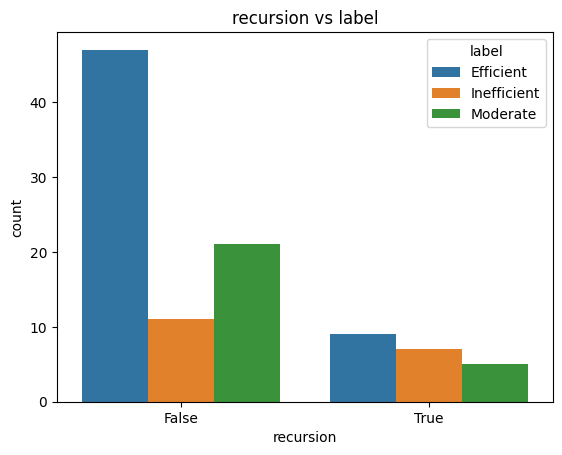

In [36]:
#recursion vs labels
sns.countplot(x="recursion", hue="label", data=df)
plt.title("recursion vs label")
plt.show()

## Light feature handling

In [37]:
df.dtypes ## recursion needs to be converted to int

code           str
loops        int64
maxDepth     int64
recursion     bool
label          str
dtype: object

In [38]:
df['recursion'] = df['recursion'].astype(int)
df.dtypes

code           str
loops        int64
maxDepth     int64
recursion    int64
label          str
dtype: object

## train test split

In [39]:
from sklearn.model_selection import train_test_split

X = df.drop(['label', 'code'], axis=1)
y = df['label']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

## Export

In [41]:
import joblib
joblib.dump((X_train, X_test, y_train, y_test), '../models/data.pkl')

['../models/data.pkl']

### done with EDA